In [2]:
import xarray
import iris
import numpy
import pathlib
import warnings
import cartopy
import matplotlib.pyplot as plt


In [3]:
def annual_mean(ds):
    """ Properly month length weighted annual mean of a DataArray"""
    if not ds.time.dt.month[0] == 1:
        raise ValueError("Data does not start with January")
    if not ds.time.dt.month[1] == 2:
        raise ValueError("Non-monthly data")
    # Process partial years
    month_length = ds.time.dt.days_in_month
    # Eventually use weighted ??? https://github.com/pydata/xarray/issues/3937
    weights = month_length.groupby('time.year') / month_length.groupby('time.year').sum()
    ann_mean = (ds*weights).groupby('time.year').sum(dim='time',min_count=1)
    return ann_mean

In [4]:
def select_fields(ds, req_fields):
    """Select only the desired fields."""
    return xarray.Dataset({v:ds[v] for v in req_fields})

In [5]:
def get_files(target_dir, year_range):
    """Get the set of files from the given run. `target_dir` should be a `Path`, and `year_range` should be a range object or None for all years."""
    netcdf_dir = target_dir / 'share/data/History_Data/netCDF'
    nc_files = []
    if year_range is not None:
        for year in year_range:
            files_for_year = netcdf_dir.glob(f'am3a.pm{year}*')
            nc_files += files_for_year
    else:
        nc_files = netcdf_dir.glob(f'am3a.pm*')

    return nc_files

In [6]:
def load_run(target_dir, desired_fields, year_range=None):
    """Load the selected fields and year range from the target run as an xarray.dataset. If year_range is not given, load all files for that run."""
    files_to_load = get_files(target_dir, year_range)

    desired_fields = desired_fields + ['time_bnds', 'lon_bnds', 'lat_bnds']

    time_coder = xarray.coders.CFDatetimeCoder(use_cftime=True)
    ds = xarray.open_mfdataset(files_to_load, combine='by_coords', decode_times=time_coder, preprocess=lambda ds: select_fields(ds, desired_fields))

    return ds

In [8]:
def get_mask(target_dir):
    """Get the mask from the target restart. The is a more selective version of the land mask-
    it also removes and points with any lake or ice fractions."""
    # The fraction of the grid box that is land
    target_rst = target_dir / 'share/data/am3a.ainitial'
    land_area_fraction = iris.load_cube(target_rst, constraint=iris.AttributeConstraint(STASH="m01s00i505"))
    land_area_fraction = xarray.DataArray.from_iris(land_area_fraction).rename({'latitude': 'lat', 'longitude': 'lon'})
    # The tile fractions
    vegetation_area_fraction = iris.load_cube(target_rst, constraint=iris.AttributeConstraint(STASH="m01s00i216"))
    vegetation_area_fraction = xarray.DataArray.from_iris(vegetation_area_fraction).rename({'pseudo_level': 'vegetation_area_fraction', 'latitude': 'lat', 'longitude': 'lon'})
    
    # Original script sets the masked locations to np.nan, so that they're not rendered on the plot. Is it easier to make it a boolean and select using a where?
    # Indices 15 and 16 are the lake and ice tiles respectively
    mask = land_area_fraction.isnull() | (land_area_fraction < 1.0) | (vegetation_area_fraction[15] > 0.0) | (vegetation_area_fraction[16] > 0.0)

    return ~mask

In [ ]:
def compute_area(ds)
    """Compute the cell areas of the target dataset, and add it as the "land_area" variable to the dataset."""
    # Assume that the grid cells are evenly spaced in latitude/longitude
    dlon = ds['lon'][2] - ds['lon'][1]
    dlat = ds['lat'][2] - ds['lat'][1]

    R_earth = 6371e3
    area_data = numpy.zeros(ds.sizes["lon"], ds.sizes["lat"] dtype=float)  
    for (j, lat) in numpy.enumerate(ds.lat):
        for (i, lon) in numpy.enumerate(ds.lon):
            area_data[i, j] = R_earth**2 * abs(sin(numpy.radians(lat - dlat * 0.5)) - sin(numpy.radians(lat - dlat * 0.5))) * dlon * 180 / numpy.pi

    area = xarray.DataArray(numpy.zeros(ds.sizes['lat'], ds.sizes['lon'], dtype=float), coords=dict(lon=ds.lon, lat=ds.lat))
    ds['land_area'] = area

In [9]:
def instantaneous_callback(cube, field, filename):
    if cube.cell_methods:
        raise iris.exceptions.IgnoreCubeException

def compute_water_change(target_dir):
    """Do water balance calculations for the restarts in the specified directory."""
    data_dir = target_dir / 'share/data/History_Data'
    init_restart = target_dir / 'share/data/am3a.ainitial'
    last_restart = list(data_dir.glob('am3a.da*'))[-1]

    # Many of the fields we don't want raise grid warnings- seems it inspects the grid before applying the constraint?
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        soil_moisture_init = xarray.DataArray.from_iris(iris.load_cube(init_restart, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH='m01s00i009')))
        soil_moisture_end = xarray.DataArray.from_iris(iris.load_cube(last_restart, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH='m01s00i009')))
        soil_moisture_total_init = soil_moisture_init.sum('depth').rename({'latitude': 'lat', 'longitude': 'lon'})
        soil_moisture_total_end = soil_moisture_end.sum('depth').rename({'latitude': 'lat', 'longitude': 'lon'})

    snow_mass_init = xarray.DataArray.from_iris(iris.load_cube(init_restart, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH='m01s00i023'))).rename({'latitude': 'lat', 'longitude': 'lon'})
    snow_mass_end = xarray.DataArray.from_iris(iris.load_cube(last_restart, callback=instantaneous_callback, constraint=iris.AttributeConstraint(STASH='m01s00i023'))).rename({'latitude': 'lat', 'longitude': 'lon'})
    
    ndays = (soil_moisture_end["time"].data - soil_moisture_init["time"].data).days

    # Net water change in kg/m^2/s
    net_change = (soil_moisture_total_end + snow_mass_end - (soil_moisture_total_init + snow_mass_init)) / (86400 * ndays)
    return net_change

In [10]:
def compute_net_water_flux(target_dir):
    """Compute the net water flux due to precipitation, runoff etc"""

    ds = load_run(target_dir, ['fld_s05i216', 'fld_s03i223', 'fld_s08i234', 'fld_s08i235'], None)
    
    # Precipitation - total_evaporation - (surface_runoff + subsurface_runoff)
    net_water_flux = (ds['fld_s05i216'] - ds['fld_s03i223'] - (ds['fld_s08i234'] + ds['fld_s08i235']))
    net_water_flux_mean = annual_mean(net_water_flux).mean('year').load()

    return net_water_flux_mean

In [ ]:
base_run_dir = pathlib.Path("/scratch/tm70/lw5085/cylc-run/access-am3-dev-n96e")
dev_run_dir = pathlib.Path("/scratch/tm70/lw5085/cylc-run/access-am3-CABLE-science-update")

am3_mask = get_mask(base_run_dir)

base_water_flux = compute_net_water_flux(base_run_dir)
dev_water_flux = compute_net_water_flux(dev_run_dir)

base_delta_water = compute_water_change(base_run_dir)
dev_delta_water = compute_water_change(dev_run_dir)


/g/data/xp65/public/apps/med_conda/envs/analysis3_edge-25.06/lib/python3.11/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i060 is on a grid 22 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3_edge-25.06/lib/python3.11/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i097 is on a grid 0 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(


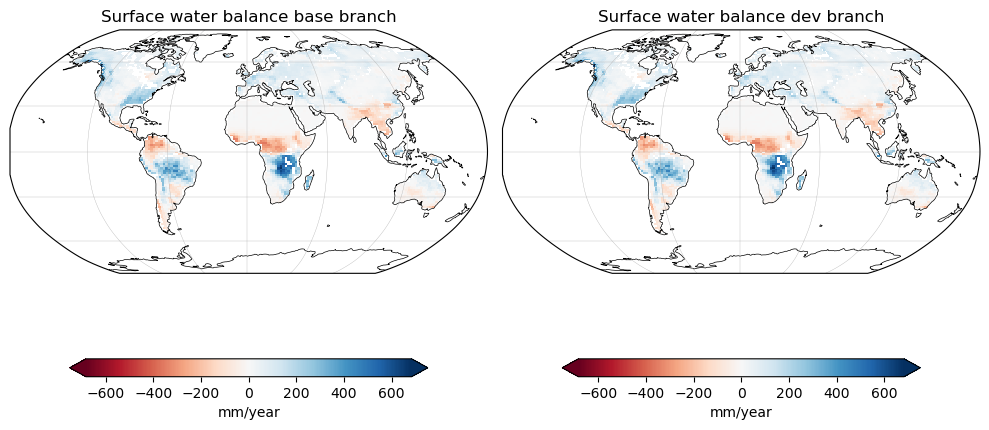

In [18]:
fig, (ax_base, ax_dev) = plt.subplots(1, 2, figsize=(10, 6), subplot_kw=dict(projection=cartopy.crs.Robinson()))
ax_base.coastlines(resolution='110m',linewidth=0.5)
ax_base.gridlines(draw_labels=False,linewidth=0.25)

ax_dev.coastlines(resolution='110m',linewidth=0.5)
ax_dev.gridlines(draw_labels=False,linewidth=0.25)

base_net_water_change = 360 * 86400 * (base_water_flux - base_delta_water).where(am3_mask)
dev_net_water_change = 360 * 86400 * (dev_water_flux - dev_delta_water).where(am3_mask)

p_base = base_net_water_change.plot(ax=ax_base, transform=cartopy.crs.PlateCarree(), add_colorbar=False, cmap='RdBu')
plt.colorbar(p_base, shrink=0.75, orientation='horizontal', extend='both', label='mm/year')
ax_base.set_title('Surface water balance base branch')

p_dev = dev_net_water_change.plot(ax=ax_dev, transform=cartopy.crs.PlateCarree(), add_colorbar=False, cmap='RdBu')
plt.colorbar(p_dev, shrink=0.75, orientation='horizontal', extend='both', label='mm/year')
ax_dev.set_title('Surface water balance dev branch')
plt.tight_layout()
plt.savefig("/scratch/rp23/lw5085/cable_science_update_water_balance.png")